# 3D Flat Notebook
Calculates energy to flatten a shell.

In [2]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

# def extents(result,frame=0):
#     Nbeads = int(np.max(result.dump_id[frame])/2)
#     botmask = result.dump_id[frame]<=(Nbeads)
#     topmask = result.dump_id[frame]>(Nbeads)
#     ytopavg = np.mean(result.dump_y[frame][topmask])
#     ybotavg = np.mean(result.dump_y[frame][botmask])
#     xmax = np.max(result.dump_x[frame])
#     xmin = np.min(result.dump_x[frame])
#     x = xmax-xmin
#     y = ytopavg-ybotavg
#     return (x,y)

# Run emin simulations - vary r0, kh

In [57]:
tstart = time.time()

dcore = 1

# t0 = 4.43 * dcore
# r0_list = [54.053]

# t0 = 2.35 * dcore
# r0_list = [32.893]

t0 = 1.2 * dcore
r0_list = [21.221]    # independent jobs that run in parallel (must be list)

# t0 = 0.8
# r0_list = [21.221]

# t0 = 0.6
# r0_list = [21.221]

#kh_list = [0.1,0.5,1,5,10] #np.linspace(5,100,20).tolist()    # dependent jobs that run in series (must be list)
kh_list = [0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.32, 0.34,
       0.36, 0.38, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56,
       0.58, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.4 , 1.5 , 1.6 , 1.7 , 1.8 , 1.9 ,
       2.  , 2.1 , 2.2 , 2.3 , 2.4 , 2.5 , 2.6 , 2.7 , 2.8 , 2.9 , 3.  ,
       3.2 , 3.4 , 3.6 , 3.8 , 4.  , 4.2 , 4.4 , 4.6 , 4.8 , 5.  ]

jobcounter = 0
for i in range(len(r0_list)):   
    
    simcounter = 0
    jobcounter += 1
    
    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")
    
    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)
    
    for j in range(len(kh_list)):  
        
        simcounter += 1
        
        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry
        dimension = 3
        dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
        wx = 30 * dcore    # mesh width in x 
        wy = 30 * dcore    # mesh width in y 
        a = 0.316 * dcore    # lattice constant of mesh
        mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
#         t0 = 1.2 * dcore    # structural thickness
        r0 = r0_list[i]   # RMS radius of curvature; set to "flat" for planar plates 
        alpha = 0.0 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
        theta = 0    # angle principal direction 1 makes with material x-axis

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0    # RMS curvature
        
        # preferred curvatures
        k01 = k_0 * np.cos(alpha)    # principal curvatures
        k02 = k_0 * np.sin(alpha)
        kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
        ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
        kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)
        

        ### Elasticity
        kh = kh_list[j]
        nuxy = 0.333
        nuz = 0.001
        kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
        kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

        ### Interactions
        pair_ints = "none" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = 1*dcore
        epsilon = 0
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        config = "stacked" #"dispersed" or "stacked"
        simtype = "emin"
        datascript = "stack3D"    # script to make data file with, NO .py EXTENSION, "stack3D", "load3D", or "lattice3D"
        nshells = 1
        datagz = True
        trajgz = True
        dumpbonds = False    # whether to calculate and dump bond data
        screen = True    # output lammps log to screen


        ### Stacked config settings
        ki1 = 0 * k01    # principal curvatures for bottom shell in stack
        ki2 = 0 * k02
        theta_i = theta
        kx_i = ki1 * np.cos(theta_i)**2 + ki2 * np.sin(theta_i)**2  # curvatures in material directions x, y, xy
        ky_i = ki1 * np.sin(theta_i)**2 + ki2 * np.cos(theta_i)**2
        kxy_i = (ki1-ki2) * np.sin(theta_i) * np.cos(theta_i)
        xlo = -2*wx
        xhi = 2*wx
        ylo = -2*wy
        yhi = 2*wy
        if r0 != 'flat':
            zlo = -4*r0
            zhi = nshells*r0 + 4*r0
        else:
            zlo = -5*(t0+dcore)
            zhi = nshells*(t0+dcore) + 5*(t0+dcore)

        ### Lattice config settings
#         Nx = 2    # number of particle columns for initial config 
#         Ny = int(nshells/Nx)
#         nshells = int(Nx*Ny)   # true number of shells in simulation
#         k_i = 0    # initial curvature of shells in lattice (need flat for high concentrations)
#         theta = "random"   # orientation of shells in lattice (0 = concave down, np.pi = concave up, "random" = randomly up or down)

        ### Dispersed config settings
#         phi = 0.1    # concentration of molecules (area fraction) - only for MD
#         v0 = wx * (t0 + dcore)    # approx area of monomer
#         lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
#         xlo = -lbox/2
#         xhi = lbox/2
#         ylo = -lbox/2
#         yhi = lbox/2
#         zlo = -0.5
#         zhi = 0.5

        ### Dynamics/Minimization Settings
        minstyle = "cg"
        etol = 1e-12
        maxiter = 100000

#         Tstart = 1.0
#         Tstop = Tstart
#         Tdamp = 10
#         seed = 15298
#         timestep = 0.0005
#         runsteps = 10000

        dumpfreq = maxiter
        thermofreq = 100

#         force  = 0.1

        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory (and .sh files) if it exists before creating again
        simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/flat/r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-{minstyle}-{int(np.abs(np.log10(etol)))}/kh-{kh:0.3f}"
        load_simpath = False # location of simulation to load in (set to False if not loading in state)
#         load_simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh_load:0.2f}/nshells-{nshells}" # location of simulation to load in (set to False if not loading in state)
#         load_dumpname = -1 # name of trajectory file to load (-1 selects highest integer found, e.g trajectory2.dump)
#         load_frame = -1    # frame number to load in (not timestep! 0 is initial state; -1 is last completed dump)

        ### Computation
        computer = "local"
#         computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 1
        tlim_min = 0
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 5 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 2    # number of cpus along x
        py = 2
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?
        
        
        #################
        ##### SETUP #####
        #################
        
        print("--------Creating simulation directory...")
        
        ### Make simulation directory
        
        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")
        
        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)
        
        ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")
        
        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file
        
units lj
dimension {dimension}
boundary s s s
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""
        
        ### Interactions
        if pair_ints == "none":
            inputcontents += "pair_style none"
        elif pair_ints == "repulsive":
            inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""
            
        else:
            if soft_ints == True:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
"""
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
"""

        
            if pair_ints == "1patch":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
"""
            elif pair_ints == "patchy":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""
                
            elif pair_ints == "attractive":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_modify shift yes
\n
"""

                
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""
#         inputcontents += f"""
# fix 3 all rigid molecule
# fix 4 all setforce NULL 0.0 NULL
# fix 4 all setforce 0.0 0.0 0.0

# group redge id {Nbeads:g} {2*Nbeads:g}
# fix 5 redge setforce {force:f} 0.0 0.0
# fix 5 redge addforce {force:f} 0.0 0.0
# group ledge id {1:g} {Nbeads+1:g}
# fix 6 ledge setforce {-force:f} 0.0 0.0
# fix 6 ledge addforce {force:f} 0.0 0.0"""

        if simtype == "emin":
            inputcontents += f"""
fix 4 all setforce NULL NULL 0.0
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes
# special_bonds lj 0.0 0.0 0.0

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
#     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)
            
        
        
        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")
        
        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    'a':a,
                    'wx':wx,
                    'wy':wy,
                    'mesh_name':mesh_name,
                    't0':t0,
                    'r0':r0,
                    'k_0':k_0,
                    'alpha':alpha,
                    'theta':theta,
                    'k01':float(k01),
                    'k02':float(k02),
                    'kx_0':float(kx_0),
                    'ky_0':float(ky_0),
                    'kxy_0':float(kxy_0)
                },
                'elasticity':{
                    'nuxy':nuxy,
                    'nuz':nuz,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)
            
        if config == "lattice":
            disp_params = {'phi':phi,"Nx":Nx,"Ny":Ny,'k_i':k_i,"theta":theta}
            params['simulation'].update(disp_params) 
         
        if config == "stacked":
            stack_params = {'ki1':float(ki1),'ki2':float(ki2),'theta_i':theta_i,'kx_i':float(kx_i),'ky_i':float(ky_i),'kxy_i':float(kxy_i)}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath,'load_dumpname':load_dumpname,'load_frame':int(load_frame)}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)
        
        
        print(f"----Simulation {simcounter} prepared.")
        
        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")
            
            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")
    
    #################################
    ##### RUN ON REMOTE CLUSTER #####
    #################################
    
    if computer != "local":
        

        ##################################
        ##### SBATCH SUBMISSION FILE #####
        ##################################

        print(f"----Writing sbatch submission file for job {jobcounter}...")
        # name of sbatch .sh file (no extension)
        if simtype == "emin":
            shname = f"nshells-{nshells}"    
        elif simtype == "md":
            shname = f"nshells-{nshells}-phi-{phi:0.5f}-kT-{kT:0.5f}"  
        ncpus = px*py*pz
        sbatchcontents = f"""#!/bin/bash
#SBATCH -N {nnodes} # Number of Nodes
#SBATCH -n {ncpus} # Number of Tasks (cpus)
#SBATCH --mem={mem}G # Requested Memory
#SBATCH -p {partition} # Partition
#SBATCH --constraint=mpi
#SBATCH -t {tlim_hrs:02d}:{tlim_min:02d}:00 # Job time limit
#SBATCH -o {JOBDIR}/{JOB}-sbatch/{shname}-%j.out # %j = job ID

### load modules
{rm.cluster_modules(computer)}

### go to project_root directory
cd {PROJECT_ROOT}

python3 -u << 'EOF' 

### python code
"""
            
        sbatchcontents += f"""
### import modules

# standard python packages
import os
import sys
import numpy as np
import subprocess
import importlib
import pathlib
#import shutil
#import yaml
#import datetime
#import pytz
import time

# utils packages and useful paths
import utils.run_manager as rm
from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
from utils.readsim import ReadSim
#JOBDIR = pathlib.Path(__file__).resolve().parents[0]    # absolute path to directory that holds this file
#JOB = os.path.splitext(os.path.basename(sys.argv[0]))[0]    # name of this file without extension
version = "{version}"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{{versionpath}}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

simtype = "{simtype}"

# dependent variables to be run in series
series_simpaths = {series_simpaths}

  
simpaths_torun = []    # list of simulations that need to be run/restarted

# sweep through variable values and find those that need to run/restart
for i in np.arange(len(series_simpaths)):
    simpath = series_simpaths[i]

    # check to see if this value has already run to completion 
    try:
        restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")    
            # returns True if in need of restart; False if completed; error if not run yet
    except:
        restartjob = True
        
    if restartjob:    # True if value needs to be run or restarted
        simpaths_torun.append(simpath)

if len(simpaths_torun) > 0:
    # For this job, select first variable value that needs to be run/restarted
    simpath = simpaths_torun[0]
    
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")
    if meta['logistics']['run_counter'] == 0:
        rc = 1
    else: 
        rc = meta['logistics']['run_counter']
    
    rm.print_header(version)
    print(f"Running {{simpath}}")
    print(f"Run number {{rc}}")
    
    # Make datafile if needed (on first run)
    if meta['logistics']['run_counter'] == 0:
        make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{{version}}")
        t1 = time.time()
        make_data(simpath)
        t2 = time.time()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,sub='logistics',params={{'datatime':t2-t1}})
        print(f"Compute time to create data file: {{rm.convert_time(t2-t1)}}")


    # Run LAMMPS
    print("Updating metadata with start time...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",start_times=True)
    print("Executing LAMMPS...")
    ncpus = {ncpus}
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")    # check what stage to use
    rm.run_lmp(simpath,"{computer}",ncpus,{screen},stage = meta['logistics']['run_counter'])
    print("Updating metadata with run info ...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",walltimes=True,steps=True,energies=True)
    if simtype == "emin":
        result = ReadSim(f"{{PROJECT_ROOT}}/{{simpath}}")
        result.read_log()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",sub="logistics",params = {{'stopcriterion':result.why_stop}})

    restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")  

    # Submit sbatch again if run hasn't completed
    if restartjob:
        if (rc < {maxrestarts}):
            print("Job incomplete.  Resubmitting...")
            sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

            jobid = int(sbatch.stdout[len('Submitted batch job '):])
            rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,submit_times=True,jobids = jobid)
        else:
            print("Error:  Exceeded max number of restarts ({maxrestarts}).")
    
    print("Done.")
    
    if len(simpaths_torun) > 1:    # resubmit this .sh file if there are more calculations to do
        print("Submitting next job.")
        simpath = simpaths_torun[1]
        sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=False,submit_times=True,jobids = jobid)


else:
    print("All variable values completed.  No runs left to do for this job.")


EOF
"""
        
        # WRITE SBATCHCONTENTS TO JOBS/*.SH (or some subdirectory)
        if delete_existing == True:
            if jobcounter == 1:
                if os.path.isdir(f"{JOBDIR}/{JOB}-sbatch"):
                    shutil.rmtree(f"{JOBDIR}/{JOB}-sbatch")
        os.makedirs(f"{JOBDIR}/{JOB}-sbatch", exist_ok=True)
        with open(f"{JOBDIR}/{JOB}-sbatch/{shname}.sh", "w") as f:
            f.write(sbatchcontents)

        ###############################
        ##### SUBMIT JOB TO QUEUE #####
        ###############################

        print(f"----Submitting job {jobcounter} to queue...")
        
        sbatch = subprocess.run(['sbatch',f"{JOBDIR}/{JOB}-sbatch/{shname}.sh"],
                                stdout=subprocess.PIPE,universal_newlines = True)
        
        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        

        ###########################
        ##### UPDATE METADATA #####
        ###########################

        print(f"----Updating metadata file...")
        rm.update_metadata(f"{PROJECT_ROOT}/{series_simpaths[0]}",submit_times=True,jobids = jobid)

        print(f"Job {jobcounter} fully prepared and submitted.\n")
        print("#####################################")
    


tend = time.time()

#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
----------Simulation directory already exists.
----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using stack3D.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 2.9013350009918213sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -84.884) to (60 60 106.105)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0     

      5700   0.18008422     0              0.18008422     0              0.18008422     0              0.00093012369
      5800   0.17898379     0              0.17898379     0              0.17898379     0              0.00088879846
      5900   0.17793516     0              0.17793516     0              0.17793516     0              0.00084882164
      6000   0.17693571     0              0.17693571     0              0.17693571     0              0.00081014869
      6100   0.17598293     0              0.17598293     0              0.17598293     0              0.00077273655
      6200   0.17507447     0              0.17507447     0              0.17507447     0              0.00073654363
      6300   0.17420808     0              0.17420808     0              0.17420808     0              0.00070152977
      6400   0.17338167     0              0.17338167     0              0.17338167     0              0.00066765613
      6500   0.17259323     0              0.17259323     0     

     12900   0.15619814     0              0.15619814     0              0.15619814     0             -0.00022280557
     13000   0.15614682     0              0.15614682     0              0.15614682     0             -0.00022663586
     13100   0.15609743     0              0.15609743     0              0.15609743     0             -0.00023034214
     13200   0.15604991     0              0.15604991     0              0.15604991     0             -0.00023392844
     13300   0.15600417     0              0.15600417     0              0.15600417     0             -0.00023739863
     13400   0.15596015     0              0.15596015     0              0.15596015     0             -0.00024075646
     13500   0.15591779     0              0.15591779     0              0.15591779     0             -0.00024400556
     13600   0.155877       0              0.155877       0              0.155877       0             -0.00024714945
     13700   0.15583775     0              0.15583775     0     

     20400   0.15488965     0              0.15488965     0              0.15488965     0             -0.00033097231
     20500   0.15488643     0              0.15488643     0              0.15488643     0             -0.00033129395
     20600   0.15488333     0              0.15488333     0              0.15488333     0             -0.00033160507
     20700   0.15488033     0              0.15488033     0              0.15488033     0             -0.00033190603
     20800   0.15487744     0              0.15487744     0              0.15487744     0             -0.00033219716
     20900   0.15487466     0              0.15487466     0              0.15487466     0             -0.00033247876
     21000   0.15487197     0              0.15487197     0              0.15487197     0             -0.00033275115
     21100   0.15486937     0              0.15486937     0              0.15486937     0             -0.00033301463
     21200   0.15486687     0              0.15486687     0     

     27500   0.15480542     0              0.15480542     0              0.15480542     0             -0.00033985244
     27600   0.15480516     0              0.15480516     0              0.15480516     0             -0.00033988206
     27700   0.15480492     0              0.15480492     0              0.15480492     0             -0.00033991068
     27800   0.15480468     0              0.15480468     0              0.15480468     0             -0.00033993834
     27900   0.15480445     0              0.15480445     0              0.15480445     0             -0.00033996507
     28000   0.15480423     0              0.15480423     0              0.15480423     0             -0.00033999091
     28100   0.15480402     0              0.15480402     0              0.15480402     0             -0.00034001587
     28200   0.15480381     0              0.15480381     0              0.15480381     0             -0.00034003999
     28300   0.15480361     0              0.15480361     0     

...

       500   4.5032178      0              4.5032178      0              4.5032178      0             -0.0098663969 
       550   4.5032178      0              4.5032178      0              4.5032178      0             -0.0098660493 
Loop time of 0.408159 on 4 procs for 550 steps with 21312 atoms

99.7% CPU use with 4 MPI tasks x no OpenMP threads

Minimization stats:
  Stopping criterion = energy tolerance
  Energy initial, next-to-last, final = 
      89.1532731982252   4.50321781339242   4.50321781338794
  Force two-norm initial, final = 11.337514 1.0497547e-05
  Force max component initial, final = 0.64025779 1.3751547e-06
  Final line search alpha, max atom move = 1 1.3751547e-06
  Iterations, force evaluations = 550 1100

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
---------------------------------------------------------------
Pair    | 0          | 0          | 0          |   0.0 |  0.00
Bond    | 0.20814    | 0.20982    | 0.21265 

...making data file
Time to create data file: 0d - 0hrs 0min 2.6974470615386963sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -84.884) to (60 60 106.105)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.073 seconds
  read_data CPU = 0.245 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 14.49 | 14.52 | 14.56 Mbytes
   Step    

Time to create data file: 0d - 0hrs 0min 2.678100824356079sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -84.884) to (60 60 106.105)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.066 seconds
  read_data CPU = 0.234 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 14.49 | 14.52 | 14.56 Mbytes
   Step         TotEng         K

  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.071 seconds
  read_data CPU = 0.242 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 14.49 | 14.52 | 14.56 Mbytes
   Step         TotEng         KinEng         PotEng         E_pair         E_bond          Temp          Press     
         0   128.15783      0              128.15783      0              128.15783      0              0.8795002    
       100   7.2080869      0              7.2080869      0              7.2080869      0             -0.037832786  
       200   6.4831

       100   7.834882       0              7.834882       0              7.834882       0             -0.041121147  
       200   7.0468563      0              7.0468563      0              7.0468563      0             -0.0157777    
       300   7.0363264      0              7.0363264      0              7.0363264      0             -0.015237768  
       400   7.0362779      0              7.0362779      0              7.0362779      0             -0.015375302  
       500   7.0362778      0              7.0362778      0              7.0362778      0             -0.015396765  
       553   7.0362778      0              7.0362778      0              7.0362778      0             -0.015396204  
Loop time of 0.405066 on 4 procs for 553 steps with 21312 atoms

99.9% CPU use with 4 MPI tasks x no OpenMP threads

Minimization stats:
  Stopping criterion = energy tolerance
  Energy initial, next-to-last, final = 
      139.301989372227   7.03627783340821   7.03627783340152
  Force two-norm in

In [58]:
print(rm.convert_time(tend-tstart))

0d - 0hrs 6min 58.74873614311218sec


# Read sims and plot

In [7]:
# kh_list = "all"
kh_list = [0.5]

# t0 = 4.434 * dcore
# r0_list = [54.053]

# t0 = 2.35 * dcore
# r0_list = [32.893]

# t0 = 1.2 * dcore
# r0_list = [21.221]

# t0 = 0.8
# r0_list = [21.221]

# t0 = 0.6
# r0_list = [21.221]

### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
# t0 = 4.434 * dcore    # structural thickness
# r0 = 50 * dcore   # RMS radius of curvature; set to "flat" for planar plates 
# r0_list = [54.053]

### Design A; eta = 0.1
t0 = 4.434
r0_list = [54.053]

### Design E; eta = 35
# t0 = 0.6
# r0_list = [21.221]

alpha = 0.0 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
theta = 0    # angle principal direction 1 makes with material x-axis

# if r0 == "flat":
#     k_0 = 0
# else:
#     k_0 = 1/r0    # RMS curvature

### Elasticity
# kh_list = [1,100]
nuxy = 0.333
nuz = 0.001
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

# kvkh = 1
# kckh = 1

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-12

r0s = []
khs = []
eflats = []
jobcounter = 0
for i in range(len(r0_list)):   
    r0 = r0_list[i]
    parentsimpath = simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/flat/r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-{minstyle}-{int(np.abs(np.log10(etol)))}"
    series_simpaths = [] # append simpaths for plotting (i.e. different kh values)
    
    if kh_list == "all":
        khlist = []
        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            kh = float(f[3:])
            khlist.append(kh)
            series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        khlist = kh_list
        for j in range(len(kh_list)):  
            kh  = kh_list[j]
            simpath = f"{parentsimpath}/kh-{kh:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
    
    r0list = []
    eflatlist = []
    for s in series_simpaths:
        logname = "log.lammps"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_log(logname=logname)
        eflat = result.energyf
        eflatlist.append(eflat)
        r0list.append(r0)
    eflats.append(eflatlist)
    r0s.append(r0list)
    khs.append(khlist)

Text(0, 0.5, 'Eflat')

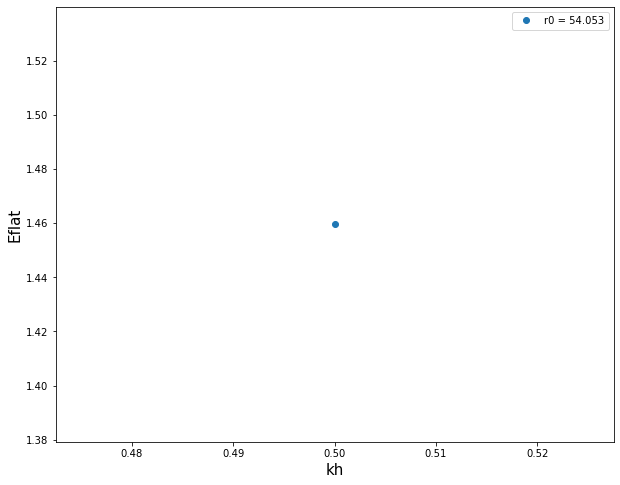

In [8]:

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(r0s)):
    ax.plot(np.array(khs[i]),np.array(eflats[i]),"o",label=f"r0 = {r0s[i][0]}")
# ax.set_xlim(0,2.5)
# ax.set_ylim(0,5)
ax.legend()
ax.set_xlabel("kh",fontsize=15)
ax.set_ylabel("Eflat",fontsize=15)


In [9]:
i = 0
print(f"t0 = {t0}")
print(f"r0 = {r0s[i][0]}")
print(f"kh_list = np.array({khs[i]})")
print(f"eflat_list = np.array({eflats[i]})")

t0 = 4.434
r0 = 54.053
kh_list = np.array([0.5])
eflat_list = np.array([1.45954877150218])


# Run emin simulations - vary r0, alpha

In [53]:
np.linspace(-45,45,41)

array([-45.  , -42.75, -40.5 , -38.25, -36.  , -33.75, -31.5 , -29.25,
       -27.  , -24.75, -22.5 , -20.25, -18.  , -15.75, -13.5 , -11.25,
        -9.  ,  -6.75,  -4.5 ,  -2.25,   0.  ,   2.25,   4.5 ,   6.75,
         9.  ,  11.25,  13.5 ,  15.75,  18.  ,  20.25,  22.5 ,  24.75,
        27.  ,  29.25,  31.5 ,  33.75,  36.  ,  38.25,  40.5 ,  42.75,
        45.  ])

In [53]:
tstart = time.time()
r0_list = [15.015]    # independent jobs that run in parallel (must be list)
alpha_list = (np.linspace(-45,45,41)*np.pi/180).tolist()    # dependent jobs that run in series (must be list)

jobcounter = 0
for i in range(len(r0_list)):   
    
    simcounter = 0
    jobcounter += 1
    
    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")
    
    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)
    
    for j in range(len(alpha_list)):  
        
        simcounter += 1
        
        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry
        dimension = 3
        dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
        wx = 30 * dcore    # mesh width in x 
        wy = 30 * dcore    # mesh width in y 
        a = 0.316 * dcore    # lattice constant of mesh
        mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
        t0 = 0.6 * dcore    # structural thickness
        r0 = r0_list[i]  # RMS radius of curvature; set to "flat" for planar plates 
        alpha = alpha_list[j]    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
        theta = 0    # angle principal direction 1 makes with material x-axis

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0    # RMS curvature
        
        # preferred curvatures
        k01 = k_0 * np.cos(alpha)    # principal curvatures
        k02 = k_0 * np.sin(alpha)
        kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
        ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
        kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)
        

        ### Elasticity
        kh = 1
        nuxy = 0.333
        nuz = 0.001
        kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
        kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

        ### Interactions
        pair_ints = "none" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = 0.25*dcore
        epsilon = 1.44848393e-05
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        config = "stacked" #"dispersed" or "stacked"
        simtype = "emin"
        datascript = "stack3D"    # script to make data file with, NO .py EXTENSION, "stack3D", "load3D", or "lattice3D"
        nshells = 1
        datagz = True
        trajgz = True
        dumpbonds = True    # whether to calculate and dump bond data
        screen = True    # output lammps log to screen


        ### Stacked config settings
        ki1 = 0 * k01    # principal curvatures for bottom shell in stack
        ki2 = 0 * k02
        theta_i = theta
        kx_i = ki1 * np.cos(theta_i)**2 + ki2 * np.sin(theta_i)**2  # curvatures in material directions x, y, xy
        ky_i = ki1 * np.sin(theta_i)**2 + ki2 * np.cos(theta_i)**2
        kxy_i = (ki1-ki2) * np.sin(theta_i) * np.cos(theta_i)
        xlo = -2*wx
        xhi = 2*wx
        ylo = -2*wy
        yhi = 2*wy
        if r0 != 'flat':
            zlo = -4*r0
            zhi = nshells*r0 + 4*r0
        else:
            zlo = -5*(t0+dcore)
            zhi = nshells*(t0+dcore) + 5*(t0+dcore)

        ### Lattice config settings
#         Nx = 2    # number of particle columns for initial config 
#         Ny = int(nshells/Nx)
#         nshells = int(Nx*Ny)   # true number of shells in simulation
#         k_i = 0    # initial curvature of shells in lattice (need flat for high concentrations)
#         theta = "random"   # orientation of shells in lattice (0 = concave down, np.pi = concave up, "random" = randomly up or down)

        ### Dispersed config settings
#         phi = 0.1    # concentration of molecules (area fraction) - only for MD
#         v0 = wx * (t0 + dcore)    # approx area of monomer
#         lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
#         xlo = -lbox/2
#         xhi = lbox/2
#         ylo = -lbox/2
#         yhi = lbox/2
#         zlo = -0.5
#         zhi = 0.5

        ### Dynamics/Minimization Settings
        minstyle = "cg"
        etol = 1e-12
        maxiter = 100000

#         Tstart = 1.0
#         Tstop = Tstart
#         Tdamp = 10
#         seed = 15298
#         timestep = 0.0005
#         runsteps = 10000

        dumpfreq = maxiter
        thermofreq = 100

#         force  = 0.1

        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory (and .sh files) if it exists before creating again
        simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/flat/r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-{minstyle}-{int(np.abs(np.log10(etol)))}/kh-{kh:0.3f}"
        load_simpath = False # location of simulation to load in (set to False if not loading in state)
#         load_simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh_load:0.2f}/nshells-{nshells}" # location of simulation to load in (set to False if not loading in state)
#         load_dumpname = -1 # name of trajectory file to load (-1 selects highest integer found, e.g trajectory2.dump)
#         load_frame = -1    # frame number to load in (not timestep! 0 is initial state; -1 is last completed dump)

        ### Computation
        computer = "local"
#         computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 1
        tlim_min = 0
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 5 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 2    # number of cpus along x
        py = 2
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?
        
        
        #################
        ##### SETUP #####
        #################
        
        print("--------Creating simulation directory...")
        
        ### Make simulation directory
        
        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")
        
        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)
        
        ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")
        
        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file
        
units lj
dimension {dimension}
boundary s s s
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""
        
        ### Interactions
        if pair_ints == "none":
            inputcontents += "pair_style none"
        elif pair_ints == "repulsive":
            inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""
            
        else:
            if soft_ints == True:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
"""
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
# upside down bonding 1
pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# upside down bonding 2
pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
"""

        
            if pair_ints == "1patch":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
"""
            elif pair_ints == "patchy":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_modify shift yes
\n
"""
                
            elif pair_ints == "attractive":
                inputcontents += f"""
# correct bonding
pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
pair_modify shift yes
\n
"""

                
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""
#         inputcontents += f"""
# fix 3 all rigid molecule
# fix 4 all setforce NULL 0.0 NULL
# fix 4 all setforce 0.0 0.0 0.0

# group redge id {Nbeads:g} {2*Nbeads:g}
# fix 5 redge setforce {force:f} 0.0 0.0
# fix 5 redge addforce {force:f} 0.0 0.0
# group ledge id {1:g} {Nbeads+1:g}
# fix 6 ledge setforce {-force:f} 0.0 0.0
# fix 6 ledge addforce {force:f} 0.0 0.0"""

        if simtype == "emin":
            inputcontents += f"""
fix 4 all setforce NULL NULL 0.0
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes
# special_bonds lj 0.0 0.0 0.0

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
#     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)
            
        
        
        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")
        
        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    'a':a,
                    'wx':wx,
                    'wy':wy,
                    'mesh_name':mesh_name,
                    't0':t0,
                    'r0':r0,
                    'k_0':k_0,
                    'alpha':alpha,
                    'theta':theta,
                    'k01':float(k01),
                    'k02':float(k02),
                    'kx_0':float(kx_0),
                    'ky_0':float(ky_0),
                    'kxy_0':float(kxy_0)
                },
                'elasticity':{
                    'nuxy':nuxy,
                    'nuz':nuz,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)
            
        if config == "lattice":
            disp_params = {'phi':phi,"Nx":Nx,"Ny":Ny,'k_i':k_i,"theta":theta}
            params['simulation'].update(disp_params) 
         
        if config == "stacked":
            stack_params = {'ki1':float(ki1),'ki2':float(ki2),'theta_i':theta_i,'kx_i':float(kx_i),'ky_i':float(ky_i),'kxy_i':float(kxy_i)}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath,'load_dumpname':load_dumpname,'load_frame':int(load_frame)}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)
        
        
        print(f"----Simulation {simcounter} prepared.")
        
        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")
            
            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")
    
    #################################
    ##### RUN ON REMOTE CLUSTER #####
    #################################
    
    if computer != "local":
        

        ##################################
        ##### SBATCH SUBMISSION FILE #####
        ##################################

        print(f"----Writing sbatch submission file for job {jobcounter}...")
        # name of sbatch .sh file (no extension)
        if simtype == "emin":
            shname = f"nshells-{nshells}"    
        elif simtype == "md":
            shname = f"nshells-{nshells}-phi-{phi:0.5f}-kT-{kT:0.5f}"  
        ncpus = px*py*pz
        sbatchcontents = f"""#!/bin/bash
#SBATCH -N {nnodes} # Number of Nodes
#SBATCH -n {ncpus} # Number of Tasks (cpus)
#SBATCH --mem={mem}G # Requested Memory
#SBATCH -p {partition} # Partition
#SBATCH --constraint=mpi
#SBATCH -t {tlim_hrs:02d}:{tlim_min:02d}:00 # Job time limit
#SBATCH -o {JOBDIR}/{JOB}-sbatch/{shname}-%j.out # %j = job ID

### load modules
{rm.cluster_modules(computer)}

### go to project_root directory
cd {PROJECT_ROOT}

python3 -u << 'EOF' 

### python code
"""
            
        sbatchcontents += f"""
### import modules

# standard python packages
import os
import sys
import numpy as np
import subprocess
import importlib
import pathlib
#import shutil
#import yaml
#import datetime
#import pytz
import time

# utils packages and useful paths
import utils.run_manager as rm
from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
from utils.readsim import ReadSim
#JOBDIR = pathlib.Path(__file__).resolve().parents[0]    # absolute path to directory that holds this file
#JOB = os.path.splitext(os.path.basename(sys.argv[0]))[0]    # name of this file without extension
version = "{version}"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{{versionpath}}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

simtype = "{simtype}"

# dependent variables to be run in series
series_simpaths = {series_simpaths}

  
simpaths_torun = []    # list of simulations that need to be run/restarted

# sweep through variable values and find those that need to run/restart
for i in np.arange(len(series_simpaths)):
    simpath = series_simpaths[i]

    # check to see if this value has already run to completion 
    try:
        restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")    
            # returns True if in need of restart; False if completed; error if not run yet
    except:
        restartjob = True
        
    if restartjob:    # True if value needs to be run or restarted
        simpaths_torun.append(simpath)

if len(simpaths_torun) > 0:
    # For this job, select first variable value that needs to be run/restarted
    simpath = simpaths_torun[0]
    
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")
    if meta['logistics']['run_counter'] == 0:
        rc = 1
    else: 
        rc = meta['logistics']['run_counter']
    
    rm.print_header(version)
    print(f"Running {{simpath}}")
    print(f"Run number {{rc}}")
    
    # Make datafile if needed (on first run)
    if meta['logistics']['run_counter'] == 0:
        make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{{version}}")
        t1 = time.time()
        make_data(simpath)
        t2 = time.time()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,sub='logistics',params={{'datatime':t2-t1}})
        print(f"Compute time to create data file: {{rm.convert_time(t2-t1)}}")


    # Run LAMMPS
    print("Updating metadata with start time...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",start_times=True)
    print("Executing LAMMPS...")
    ncpus = {ncpus}
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")    # check what stage to use
    rm.run_lmp(simpath,"{computer}",ncpus,{screen},stage = meta['logistics']['run_counter'])
    print("Updating metadata with run info ...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",walltimes=True,steps=True,energies=True)
    if simtype == "emin":
        result = ReadSim(f"{{PROJECT_ROOT}}/{{simpath}}")
        result.read_log()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",sub="logistics",params = {{'stopcriterion':result.why_stop}})

    restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")  

    # Submit sbatch again if run hasn't completed
    if restartjob:
        if (rc < {maxrestarts}):
            print("Job incomplete.  Resubmitting...")
            sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

            jobid = int(sbatch.stdout[len('Submitted batch job '):])
            rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,submit_times=True,jobids = jobid)
        else:
            print("Error:  Exceeded max number of restarts ({maxrestarts}).")
    
    print("Done.")
    
    if len(simpaths_torun) > 1:    # resubmit this .sh file if there are more calculations to do
        print("Submitting next job.")
        simpath = simpaths_torun[1]
        sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=False,submit_times=True,jobids = jobid)


else:
    print("All variable values completed.  No runs left to do for this job.")


EOF
"""
        
        # WRITE SBATCHCONTENTS TO JOBS/*.SH (or some subdirectory)
        if delete_existing == True:
            if jobcounter == 1:
                if os.path.isdir(f"{JOBDIR}/{JOB}-sbatch"):
                    shutil.rmtree(f"{JOBDIR}/{JOB}-sbatch")
        os.makedirs(f"{JOBDIR}/{JOB}-sbatch", exist_ok=True)
        with open(f"{JOBDIR}/{JOB}-sbatch/{shname}.sh", "w") as f:
            f.write(sbatchcontents)

        ###############################
        ##### SUBMIT JOB TO QUEUE #####
        ###############################

        print(f"----Submitting job {jobcounter} to queue...")
        
        sbatch = subprocess.run(['sbatch',f"{JOBDIR}/{JOB}-sbatch/{shname}.sh"],
                                stdout=subprocess.PIPE,universal_newlines = True)
        
        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        

        ###########################
        ##### UPDATE METADATA #####
        ###########################

        print(f"----Updating metadata file...")
        rm.update_metadata(f"{PROJECT_ROOT}/{series_simpaths[0]}",submit_times=True,jobids = jobid)

        print(f"Job {jobcounter} fully prepared and submitted.\n")
        print("#####################################")
    


tend = time.time()

#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using stack3D.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 3.687340021133423sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -60.06) to (60 60 75.075)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = ma

...making data file
Time to create data file: 0d - 0hrs 0min 3.655762195587158sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -60.06) to (60 60 75.075)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.089 seconds
  read_data CPU = 0.305 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step       

  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.101 seconds
  read_data CPU = 0.313 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step         TotEng         KinEng         PotEng         E_pair         E_bond          Temp          Press     
         0   86.399063      0              86.399063      0              86.399063      0              0.78457808   
       100   3.8448262      0              3.8448262      0              3.8448262      0              0.033966177  
       200   3.2966

Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step         TotEng         KinEng         PotEng         E_pair         E_bond          Temp          Press     
         0   88.32957       0              88.32957       0              88.32957       0              0.78223137   
       100   3.573891       0              3.573891       0              3.573891       0              0.028177065  
       200   2.9606078      0              2.9606078      0              2.9606078      0             -0.0034135705 
       300   2.9416491      0              2.9416491      0              2.9416491      0             -0.00071543898
       400   2.9416114      0              2.9416114      0              2.9416114      0             -0.0005875892 
       500   2.9416112      0              2.9416112      0              2.9416112      0             -0.00061482199
       596   2.9416112      0              2.9416112      0              2.9416112      0             -0.

Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step         TotEng         KinEng         PotEng         E_pair         E_bond          Temp          Press     
         0   90.681         0              90.681         0              90.681         0              0.77973243   
       100   3.2595123      0              3.2595123      0              3.2595123      0              0.02317773   
       200   2.5403505      0              2.5403505      0              2.5403505      0             -0.0041359928 
       300   2.5150805      0              2.5150805      0              2.5150805      0             -0.00070489351
       400   2.5150116      0              2.5150116      0              2.5150116      0             -0.00055555205
       500   2.5150113      0              2.5150113      0              2.5150113      0             -0.00059384017
       600   2.5150113      0              2.5150113      0              2.5150113      0             -0.

...

Time to create data file: 0d - 0hrs 0min 3.656787872314453sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -60.06) to (60 60 75.075)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.083 seconds
  read_data CPU = 0.298 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step         TotEng         Kin

...making data file
Time to create data file: 0d - 0hrs 0min 3.6433937549591064sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -60.06) to (60 60 75.075)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.087 seconds
  read_data CPU = 0.302 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step      

...making data file
Time to create data file: 0d - 0hrs 0min 3.647144079208374sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -60.06) to (60 60 75.075)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.089 seconds
  read_data CPU = 0.301 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step       

...making data file
Time to create data file: 0d - 0hrs 0min 3.6854283809661865sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -60.06) to (60 60 75.075)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.097 seconds
  read_data CPU = 0.323 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step      

...making data file
Time to create data file: 0d - 0hrs 0min 3.633409023284912sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -60.06) to (60 60 75.075)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  21312 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  137316 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.100 seconds
  read_data CPU = 0.312 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory allocation (min/avg/max) = 20.52 | 20.56 | 20.59 Mbytes
   Step       

In [54]:
print(rm.convert_time(tend-tstart))

0d - 0hrs 3min 49.0957887172699sec


# Read and plot - vary r0, alpha

In [55]:

### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
# t0 = 0.2 * dcore    # structural thickness
# r0 = 50 * dcore   # RMS radius of curvature; set to "flat" for planar plates 
# r0_list = [10,25,50]
# alpha = -np.pi/4    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle)
alpha_list = (np.linspace(-45,45,41)*np.pi/180).tolist()
theta = 0    # angle principal direction 1 makes with material x-axis

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

### Elasticity
kh = 1
# nuxy = 0.33
# nuz = 0.01
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)
# kvkh = 1 
# kckh = 1 

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-12



r0s = []
alphas = []
eflats = []
jobcounter = 0
for i in range(len(r0_list)):   
    r0 = r0_list[i]
#     parentsimpath = simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/flat/r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-{minstyle}-{int(np.abs(np.log10(etol)))}"
    series_simpaths = [] # append simpaths for plotting (i.e. different kh values)
    
    for j in range(len(alpha_list)):  
        alpha  = alpha_list[j]
        simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/flat/r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-{minstyle}-{int(np.abs(np.log10(etol)))}/kh-{kh:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)
        series_simpaths.append(simpath)
    
    r0list = []
    eflatlist = []
    for s in series_simpaths:
        logname = "log.lammps"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_log(logname=logname)
        eflat = result.energyf
        eflatlist.append(eflat)
        r0list.append(r0)
    eflats.append(eflatlist)
    r0s.append(r0list)
    alphas.append(alpha_list)

In [56]:
def eflat_theory(eta,alpha,nu):
    return 0.5*( eta * np.cos(alpha)**2 * np.sin(alpha)**2  + np.cos(alpha)**2 + np.sin(alpha)**2 + 2*nu*np.cos(alpha) * np.sin(alpha) )

Text(0, 0.5, 'Eflat')

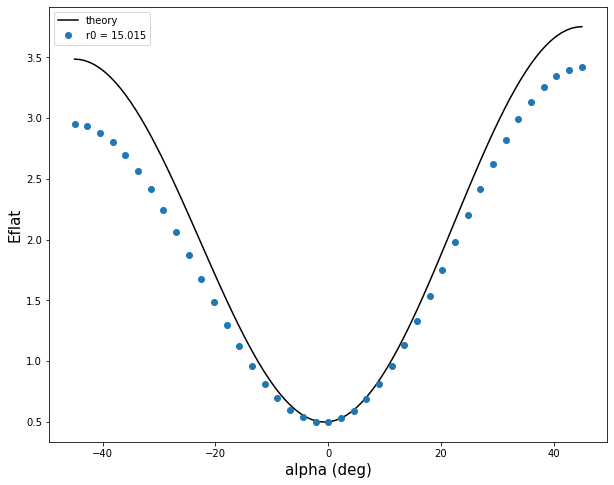

In [57]:
nutheory = 0.267
fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in np.arange(len(r0s)):
    atheory = np.linspace(-45 *np.pi/180,45*np.pi/180,100)
    etheory = 1*eflat_theory(0.0025*wx**4/(t0**2 * r0s[i][0]**2),atheory,nutheory)
    if i == 0:
        ax.plot(atheory*180/np.pi,etheory,"k-",label="theory")
    else:
        ax.plot(atheory*180/np.pi,etheory,"k-")

    icyl = np.array(alphas[i]) == 0
    ecyl = np.array(eflats[i])[icyl]
    ax.plot(np.array(alphas[i])*180/np.pi,np.array(eflats[i])/(2*ecyl),"o",label=f"r0 = {r0s[i][0]}")
# ax.set_xlim(0,1.5)
# ax.set_ylim(0,0.6)
ax.legend()
ax.set_xlabel("alpha (deg)",fontsize=15)
ax.set_ylabel("Eflat",fontsize=15)



In [58]:
np.array(alphas[i])*180/np.pi

array([-45.  , -42.75, -40.5 , -38.25, -36.  , -33.75, -31.5 , -29.25,
       -27.  , -24.75, -22.5 , -20.25, -18.  , -15.75, -13.5 , -11.25,
        -9.  ,  -6.75,  -4.5 ,  -2.25,   0.  ,   2.25,   4.5 ,   6.75,
         9.  ,  11.25,  13.5 ,  15.75,  18.  ,  20.25,  22.5 ,  24.75,
        27.  ,  29.25,  31.5 ,  33.75,  36.  ,  38.25,  40.5 ,  42.75,
        45.  ])

In [59]:
np.array(eflats[i])/(2*ecyl)

array([2.95108493, 2.93108265, 2.8809954 , 2.80207898, 2.69628597,
       2.56621984, 2.41507509, 2.2465645 , 2.06483477, 1.87437203,
       1.67989901, 1.48626568, 1.29833575, 1.12087138, 0.95841865,
       0.81519668, 0.69499301, 0.60106805, 0.53607119, 0.50197076,
       0.5       , 0.53062042, 0.59350375, 0.68753309, 0.81082327,
       0.96076019, 1.13405828, 1.32683478, 1.53469934, 1.75285687,
       1.97622143, 2.19953854, 2.41751302, 2.62493937, 2.81683147,
       2.98854818, 3.13591169, 3.25531534, 3.34381787, 3.39922145,
       3.42013118])

In [60]:
ecyl[0]

0.609010305401894

Text(0, 0.5, 'Eflat')

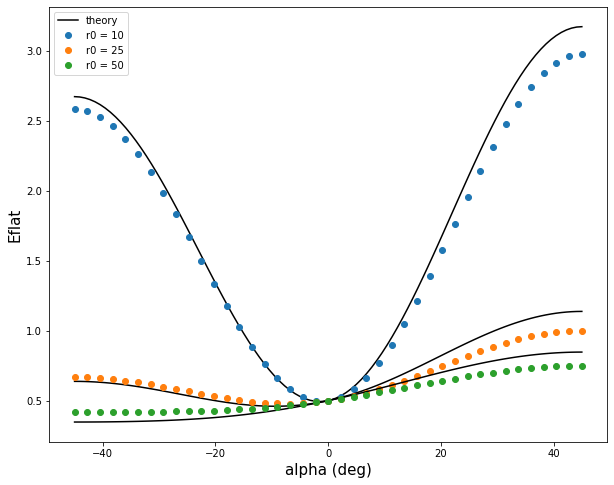

In [184]:
fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in np.arange(len(r0s)):
    atheory = np.linspace(-45 *np.pi/180,45*np.pi/180,100)
    etheory = 1*eflat_theory(0.0025*wx**4/(t0**2 * r0s[i][0]**2),atheory,0.5)
    if i == 0:
        ax.plot(atheory*180/np.pi,etheory,"k-",label="theory")
    else:
        ax.plot(atheory*180/np.pi,etheory,"k-")

    icyl = np.array(alphas[i]) == 0
    ecyl = np.array(eflats[i])[icyl]
    ax.plot(np.array(alphas[i])*180/np.pi,np.array(eflats[i])/(2*ecyl),"o",label=f"r0 = {r0s[i][0]}")
# ax.set_xlim(0,1.5)
# ax.set_ylim(0,0.6)
ax.legend()
ax.set_xlabel("alpha (deg)",fontsize=15)
ax.set_ylabel("Eflat",fontsize=15)